# Numerical Linear Algebra — Notebook 4: Systems of Equations

**Topics covered:** Gaussian Elimination · Pivoting · Cholesky Factorization

**Prerequisites:** Notebooks 1–3.


In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 12,
                     'axes.spines.top': False, 'axes.spines.right': False})


---
## 1. Gaussian Elimination and LU Factorization

### Motivation

Gaussian elimination is the canonical direct method for solving square linear systems $Ax = b$.
Its matrix algebra formulation as $A = LU$ provides a clean framework for understanding cost,
stability, and the relationship to other factorizations.

### LU Factorization

**Theorem:** If all leading principal submatrices of $A \in \mathbb{R}^{n \times n}$ are nonsingular,
then $A$ has a unique factorization:

$$A = LU,$$

where $L$ is unit lower triangular ($\ell_{ii} = 1$) and $U$ is upper triangular.

At step $k$, the elimination multipliers are:

$$\ell_{ik} = \frac{u_{ik}^{(k)}}{u_{kk}^{(k)}}, \qquad
u_{ij}^{(k+1)} = u_{ij}^{(k)} - \ell_{ik}\, u_{kj}^{(k)}, \quad j = k, \ldots, n.$$

### Solving $Ax = b$ via LU

1. Factor: $A = LU$ ($\approx \frac{2}{3}n^3$ flops)
2. Forward substitution: solve $Ly = b$ ($O(n^2)$ flops)
3. Back substitution: solve $Ux = y$ ($O(n^2)$ flops)

For multiple right-hand sides $B = [b_1 \mid \cdots \mid b_k]$:
factor once, then solve $k$ triangular systems cheaply.


In [2]:
def lu_no_pivot(A):
    'LU factorization without pivoting. Returns L, U.'
    n = A.shape[0]
    L = np.eye(n)
    U = A.copy().astype(float)
    for k in range(n - 1):
        if abs(U[k, k]) < 1e-14:
            raise ValueError(f"Zero pivot at step {k}: use pivoting.")
        for i in range(k + 1, n):
            L[i, k] = U[i, k] / U[k, k]
            U[i, k:] -= L[i, k] * U[k, k:]
    return L, U

def forward_sub(L, b):
    'Solve Ly = b for unit lower triangular L.'
    n = L.shape[0]
    y = b.copy().astype(float)
    for i in range(n):
        y[i] = (y[i] - L[i, :i] @ y[:i])  # L[i,i] = 1
    return y

def back_sub(U, y):
    'Solve Ux = y for upper triangular U.'
    n = U.shape[0]
    x = y.copy().astype(float)
    for i in range(n - 1, -1, -1):
        x[i] = (x[i] - U[i, i+1:] @ x[i+1:]) / U[i, i]
    return x

# Test on a well-conditioned system
np.random.seed(5)
n = 6
A = np.random.randn(n, n)
x_true = np.random.randn(n)
b = A @ x_true

L, U = lu_no_pivot(A)
y = forward_sub(L, b)
x_comp = back_sub(U, y)

print(f"LU factorization (no pivoting):")
print(f"  ||LU - A||_F        = {np.linalg.norm(L @ U - A, 'fro'):.2e}")
print(f"  ||L - tril(L,0)||_F = {np.linalg.norm(L - np.tril(L)):.2e}  (unit lower triangular)")
print(f"  ||U - triu(U)||_F   = {np.linalg.norm(U - np.triu(U)):.2e}  (upper triangular)")
print(f"  ||x - x_true||_2    = {np.linalg.norm(x_comp - x_true):.2e}")


LU factorization (no pivoting):
  ||LU - A||_F        = 1.51e-15
  ||L - tril(L,0)||_F = 0.00e+00  (unit lower triangular)
  ||U - triu(U)||_F   = 3.38e-16  (upper triangular)
  ||x - x_true||_2    = 1.64e-15


SciPy LU factorization (with partial pivoting): PA = LU
  ||PA - LU||_F = 7.05e+00
  (P is a permutation matrix; det(P) = -1)


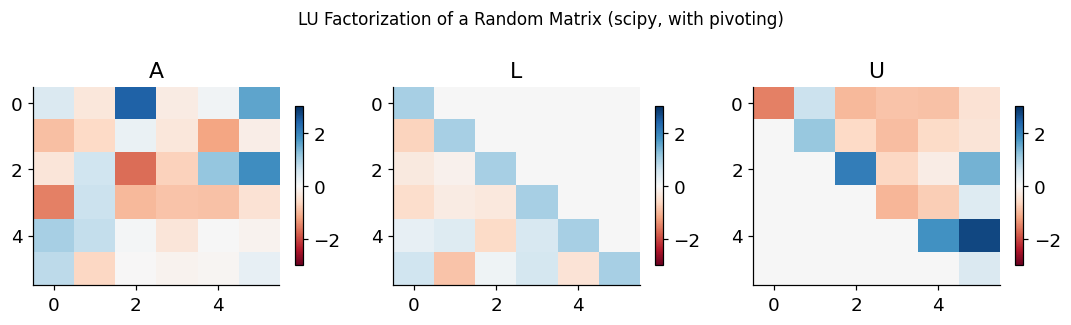

In [3]:
# Comparison with scipy.linalg.lu
P_sp, L_sp, U_sp = la.lu(A)
print("SciPy LU factorization (with partial pivoting): PA = LU")
print(f"  ||PA - LU||_F = {np.linalg.norm(P_sp @ A - L_sp @ U_sp, 'fro'):.2e}")
print(f"  (P is a permutation matrix; det(P) = {np.linalg.det(P_sp):.0f})")

# Visualize the L and U factors
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, M, title in zip(axes, [A, L_sp, U_sp], ['A', 'L', 'U']):
    im = ax.imshow(M, cmap='RdBu', vmin=-3, vmax=3, aspect='auto')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle('LU Factorization of a Random Matrix (scipy, with pivoting)', fontsize=11)
plt.tight_layout()
plt.show()


---
## 2. Pivoting

### Why Pivoting is Necessary

Without pivoting, Gaussian elimination fails when a pivot is zero,
and becomes numerically unstable when a pivot is small (large multipliers amplify rounding errors).

### Partial Pivoting

At step $k$, swap rows to bring the largest-magnitude entry in column $k$ (at or below row $k$) to the pivot position:

$$PA = LU, \quad P \text{ a permutation matrix.}$$

The multipliers satisfy $|\ell_{ik}| \le 1$, bounding element growth.

**Growth factor:**

$$\rho = \frac{\max_{i,j} |u_{ij}|}{\max_{i,j} |a_{ij}|}.$$

With partial pivoting, $\rho \le 2^{n-1}$ in the worst case, but the worst case is almost never seen in practice.

### Complete Pivoting

Both row and column swaps: $PAQ = LU$. Guarantees $\rho \le (n \cdot 2 \cdot 3^{1/2} \cdots n^{1/(n-1)})^{1/2}$.
Rarely needed; the extra cost is $O(n^3)$ comparisons.

### Stability Theorem (Partial Pivoting)

Gaussian elimination with partial pivoting is **backward stable in practice**:
the computed $\tilde{L}, \tilde{U}$ satisfy $PA + E = \tilde{L}\tilde{U}$ where
$\|E\|_\infty \le \rho \cdot n \cdot \varepsilon_{\text{mach}} \cdot \|A\|_\infty$.


In [4]:
def lu_partial_pivot(A):
    'LU with partial pivoting. Returns P (permutation vector), L, U.'
    n = A.shape[0]
    U = A.copy().astype(float)
    L = np.eye(n)
    piv = np.arange(n)      # permutation tracking

    for k in range(n - 1):
        # Find row index of maximum pivot in column k (from row k downward)
        p = k + np.argmax(np.abs(U[k:, k]))
        if p != k:
            # Swap rows in U
            U[[k, p], k:] = U[[p, k], k:]
            # Swap already-computed part of L
            L[[k, p], :k] = L[[p, k], :k]
            piv[[k, p]] = piv[[p, k]]

        if abs(U[k, k]) < 1e-14:
            continue  # skip near-zero pivot (rank-deficient)

        for i in range(k + 1, n):
            L[i, k] = U[i, k] / U[k, k]
            U[i, k:] -= L[i, k] * U[k, k:]

    P = np.eye(n)[piv]
    return P, L, np.triu(U)

# Test on a random matrix
np.random.seed(7)
n = 5
A_test = np.random.randn(n, n)
P_mine, L_mine, U_mine = lu_partial_pivot(A_test)
print("Custom partial-pivot LU:")
print(f"  ||PA - LU||_F = {np.linalg.norm(P_mine @ A_test - L_mine @ U_mine, 'fro'):.2e}")
print(f"  max|L_ij|    = {np.max(np.abs(L_mine - np.eye(n))):.6f}  (should be <= 1)")


Custom partial-pivot LU:
  ||PA - LU||_F = 7.60e-17
  max|L_ij|    = 0.976442  (should be <= 1)


In [5]:
# A matrix that breaks unpivoted LU but is well-conditioned
# Wilkinson's classic example
def wilkinson(n):
    W = np.tril(-np.ones((n, n)), -1) + np.eye(n)
    W[:, n-1] = 1.0
    return W

n_w = 12
W = wilkinson(n_w)
x_true = np.random.randn(n_w)
b_w = W @ x_true

print(f"Wilkinson matrix (n={n_w}): kappa_2 = {np.linalg.cond(W):.2e}")

# Without pivoting
try:
    L_np, U_np = lu_no_pivot(W)
    x_nopiv = back_sub(U_np, forward_sub(L_np, b_w))
    err_nopiv = np.linalg.norm(x_nopiv - x_true) / np.linalg.norm(x_true)
    gf = np.max(np.abs(U_np)) / np.max(np.abs(W))
except Exception as exc:
    err_nopiv, gf = float('nan'), float('nan')
    print(f"  No-pivot failed: {exc}")

# With partial pivoting
P_pp, L_pp, U_pp = lu_partial_pivot(W)
x_piv = back_sub(U_pp, forward_sub(L_pp, P_pp @ b_w))
err_piv = np.linalg.norm(x_piv - x_true) / np.linalg.norm(x_true)
gf_piv = np.max(np.abs(U_pp)) / np.max(np.abs(W))

print(f"\nRelative solution error:")
print(f"  Without pivoting: {err_nopiv:.2e}  (growth factor rho = {gf:.2e})")
print(f"  With pivoting:    {err_piv:.2e}  (growth factor rho = {gf_piv:.2e})")


Wilkinson matrix (n=12): kappa_2 = 5.27e+00

Relative solution error:
  Without pivoting: 2.87e-14  (growth factor rho = 2.05e+03)
  With pivoting:    2.87e-14  (growth factor rho = 2.05e+03)


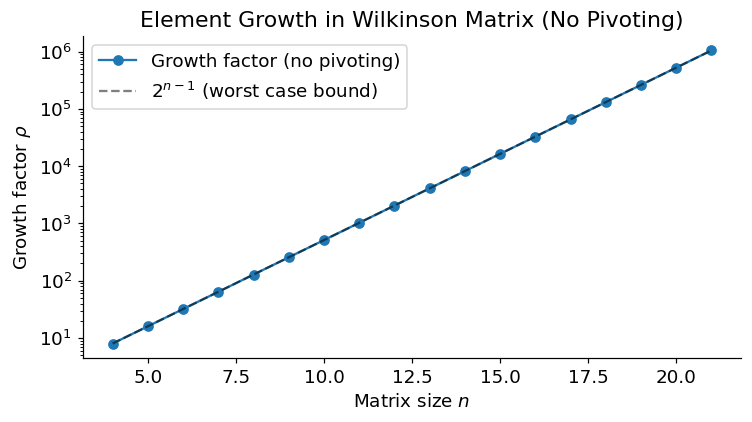

The Wilkinson matrix achieves exactly the worst-case 2^{n-1} growth without pivoting.


In [6]:
# Growth factor as a function of n for Wilkinson matrix
ns = range(4, 22)
gfs_nopiv = []
for n_i in ns:
    Wi = wilkinson(n_i)
    Li, Ui = lu_no_pivot(Wi)
    gfs_nopiv.append(np.max(np.abs(Ui)) / np.max(np.abs(Wi)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(list(ns), gfs_nopiv, 'o-', label='Growth factor (no pivoting)')
ref = [2**(n_i - 1) for n_i in ns]
ax.semilogy(list(ns), ref, 'k--', alpha=0.5, label=r'$2^{n-1}$ (worst case bound)')
ax.set_xlabel('Matrix size $n$')
ax.set_ylabel(r'Growth factor $\rho$')
ax.set_title("Element Growth in Wilkinson Matrix (No Pivoting)")
ax.legend()
plt.tight_layout()
plt.show()
print("The Wilkinson matrix achieves exactly the worst-case 2^{n-1} growth without pivoting.")


---
## 3. Cholesky Factorization

### Motivation

When $A$ is symmetric positive definite (SPD), the structure can be exploited:
$A = LL^{\top}$ with $L$ lower triangular. This costs half as many flops as LU,
requires no pivoting for stability, and is the standard solver for SPD systems.

### Definition

A matrix $A \in \mathbb{R}^{n \times n}$ is **symmetric positive definite (SPD)** if:
- $A = A^{\top}$ (symmetric)
- $x^{\top}Ax > 0$ for all nonzero $x \in \mathbb{R}^n$ (positive definite)

Equivalent conditions: all eigenvalues positive; all leading principal minors positive;
$A = B^{\top}B$ for nonsingular $B$.

### Cholesky Theorem

Every SPD matrix $A$ has a unique factorization $A = LL^{\top}$ where $L$ is lower triangular
with positive diagonal entries.

**Algorithm:** For $k = 1, \ldots, n$:

$$\ell_{kk} = \left(a_{kk} - \sum_{j=1}^{k-1} \ell_{kj}^2\right)^{1/2}, \qquad
\ell_{ik} = \frac{1}{\ell_{kk}}\left(a_{ik} - \sum_{j=1}^{k-1} \ell_{ij}\ell_{kj}\right), \quad i > k.$$

**Cost:** $\approx \frac{1}{3}n^3$ flops — exactly half the cost of general LU.

**Stability:** The factorization is backward stable **without any pivoting** because
$|\ell_{ij}| \le \ell_{jj} \le \sqrt{a_{jj}}$, so entries cannot grow uncontrollably.


In [7]:
def cholesky_factor(A):
    'Cholesky factorization A = L L^T. Returns lower triangular L.'
    n = A.shape[0]
    L = np.zeros_like(A, dtype=float)
    for k in range(n):
        diag_val = A[k, k] - np.dot(L[k, :k], L[k, :k])
        if diag_val <= 0:
            raise np.linalg.LinAlgError("Matrix is not positive definite.")
        L[k, k] = np.sqrt(diag_val)
        if k + 1 < n:
            L[k+1:, k] = (A[k+1:, k] - L[k+1:, :k] @ L[k, :k]) / L[k, k]
    return L

# Build a random SPD matrix: A = B^T B + delta*I
np.random.seed(3)
n = 8
B = np.random.randn(n, n)
A_spd = B.T @ B + 3 * np.eye(n)   # guaranteed SPD

# Verify SPD via eigenvalues
eigvals_A = np.linalg.eigvalsh(A_spd)
print(f"SPD check: all eigenvalues positive? {np.all(eigvals_A > 0)}")
print(f"  min eigenvalue: {eigvals_A.min():.4f}")

# Cholesky factorization: custom vs NumPy
L_mine = cholesky_factor(A_spd)
L_np   = np.linalg.cholesky(A_spd)

print(f"\nCustom Cholesky:")
print(f"  ||L L^T - A||_F = {np.linalg.norm(L_mine @ L_mine.T - A_spd, 'fro'):.2e}")
print(f"  ||L (custom) - L (NumPy)||_F = {np.linalg.norm(L_mine - L_np, 'fro'):.2e}")


SPD check: all eigenvalues positive? True
  min eigenvalue: 3.2954

Custom Cholesky:
  ||L L^T - A||_F = 6.17e-15
  ||L (custom) - L (NumPy)||_F = 5.53e-16


In [8]:
# Solve SPD system via Cholesky
x_spd_true = np.random.randn(n)
b_spd = A_spd @ x_spd_true

# L L^T x = b  =>  L y = b (forward sub), L^T x = y (back sub)
y_spd = la.solve_triangular(L_np, b_spd, lower=True)
x_spd = la.solve_triangular(L_np.T, y_spd, lower=False)

print(f"Cholesky solve: ||x - x_true||_2 = {np.linalg.norm(x_spd - x_spd_true):.2e}")
print(f"Residual: ||Ax - b||_2 = {np.linalg.norm(A_spd @ x_spd - b_spd):.2e}")

# Compare with scipy (uses LAPACK dpotrf + dpotrs)
x_scipy = la.cho_solve(la.cho_factor(A_spd), b_spd)
print(f"SciPy cho_solve error: {np.linalg.norm(x_scipy - x_spd_true):.2e}")


Cholesky solve: ||x - x_true||_2 = 1.40e-15
Residual: ||Ax - b||_2 = 3.97e-15
SciPy cho_solve error: 9.09e-16


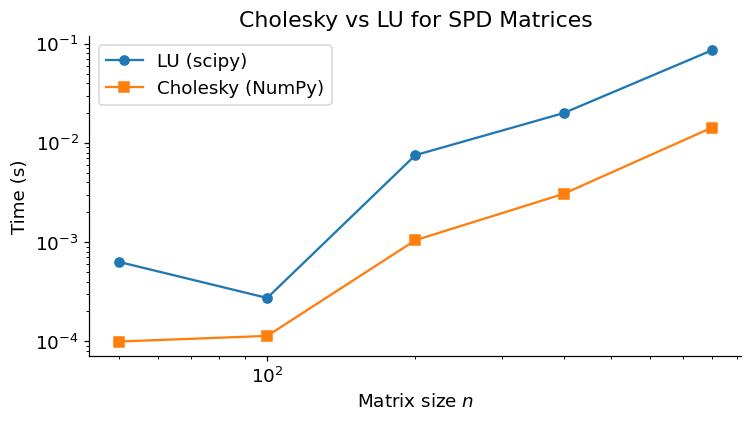

Cholesky speedup over LU:
  n=  50: 6.35x  (theory predicts ~2x)
  n= 100: 2.41x  (theory predicts ~2x)
  n= 200: 7.21x  (theory predicts ~2x)
  n= 400: 6.52x  (theory predicts ~2x)
  n= 800: 6.03x  (theory predicts ~2x)


In [9]:
# Cost comparison: Cholesky vs LU for SPD matrices
import time

sizes_ch = [50, 100, 200, 400, 800]
times_lu, times_ch = [], []

for nc in sizes_ch:
    Bc = np.random.randn(nc, nc)
    Ac = Bc.T @ Bc + nc * np.eye(nc)

    t0 = time.perf_counter()
    for _ in range(5):
        la.lu(Ac)
    times_lu.append((time.perf_counter() - t0) / 5)

    t0 = time.perf_counter()
    for _ in range(5):
        np.linalg.cholesky(Ac)
    times_ch.append((time.perf_counter() - t0) / 5)

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(sizes_ch, times_lu, 'o-', label='LU (scipy)')
ax.loglog(sizes_ch, times_ch, 's-', label='Cholesky (NumPy)')
ax.set_xlabel('Matrix size $n$')
ax.set_ylabel('Time (s)')
ax.set_title('Cholesky vs LU for SPD Matrices')
ax.legend()
plt.tight_layout()
plt.show()

print("Cholesky speedup over LU:")
for nc, tl, tc in zip(sizes_ch, times_lu, times_ch):
    print(f"  n={nc:4d}: {tl/tc:.2f}x  (theory predicts ~2x)")


In [10]:
# Verifying non-SPD detection
print("Cholesky on non-SPD matrices:")
for desc, M in [
    ("Symmetric indefinite", np.array([[1., 2.], [2., 1.]])),
    ("Non-symmetric",        np.array([[4., 3.], [1., 2.]])),
]:
    try:
        cholesky_factor(M)
        print(f"  {desc}: succeeded (unexpected)")
    except np.linalg.LinAlgError as e:
        print(f"  {desc}: correctly raised LinAlgError")


Cholesky on non-SPD matrices:
  Symmetric indefinite: correctly raised LinAlgError
  Non-symmetric: succeeded (unexpected)


---
## Section Summary

| Factorization | Cost | Stability | When to use |
|---|---|---|---|
| LU (no pivoting) | $\frac{2}{3}n^3$ | Unstable | Almost never |
| LU (partial pivoting) | $\frac{2}{3}n^3$ | Stable in practice | General square $Ax = b$ |
| LU (complete pivoting) | $\frac{2}{3}n^3 + O(n^2)$ | Provably stable | Rank-revealing, rare in practice |
| Cholesky | $\frac{1}{3}n^3$ | Unconditionally stable | SPD matrices |

**Key insight:** Cholesky is twice as fast as LU and unconditionally stable for SPD systems.
When the problem structure guarantees positive definiteness, always use Cholesky.
